In [1]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

# Não modifique esta função

def read_idx(filename):
    with open(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

def load_data(path_imags, path_labels):
    X = read_idx(path_imags)
    y = read_idx(path_labels)

    X= X.astype('float32')
    X /= 255

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

    return X_train, y_train, X_test, y_test

Dataset shape: 48000 [n_images,hight,width]


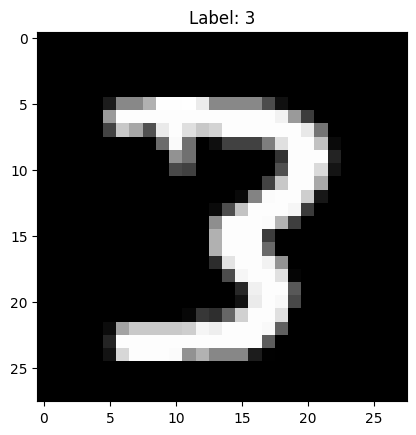

In [2]:
imgs = 'train-images.idx3-ubyte'
labels = 'train-labels.idx1-ubyte'
X_train, y_train, X_test, y_test = load_data(imgs, labels)
print('Dataset shape:', X_train.shape[0], "[n_images,hight,width]")
plt.imshow(X_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Camada de saída

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['acc'])

    return model

In [4]:
create_model((28, 28), 10).summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,018 (207.10 KB)

 Trainable params: 53,018 (207.10 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:


def read_idx(filename):
    with open(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

def load_data(path_imags, path_labels):
    X = read_idx(path_imags)
    y = read_idx(path_labels)

    X= X.astype('float32')
    X /= 255

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

    return X_train, y_train, X_test, y_test

def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Camada de saída

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['acc'])

    return model

def train_model(model,train_data, test_data, batch_size=32, epochs=5):
    history = model.fit(train_data[0],train_data[1],
                    validation_data=test_data,
                    batch_size=batch_size,
                    epochs=epochs,
                    shuffle=True,
                    verbose=2)
    return history

imgs = 'train-images.idx3-ubyte'
labels = 'train-labels.idx1-ubyte'

X_train, y_train, X_test, y_test = load_data(imgs, labels)

model = create_model((28, 28), 10)

model_trained = train_model(model, (X_train, y_train), (X_test, y_test), batch_size=32, epochs=10)

Epoch 1/10
1500/1500 - 7s - 5ms/step - acc: 0.8888 - loss: 0.3651 - val_acc: 0.9368 - val_loss: 0.1992
Epoch 2/10
1500/1500 - 4s - 2ms/step - acc: 0.9532 - loss: 0.1532 - val_acc: 0.9583 - val_loss: 0.1354
Epoch 3/10
1500/1500 - 6s - 4ms/step - acc: 0.9679 - loss: 0.1070 - val_acc: 0.9618 - val_loss: 0.1226
Epoch 4/10
1500/1500 - 5s - 3ms/step - acc: 0.9728 - loss: 0.0881 - val_acc: 0.9626 - val_loss: 0.1253
Epoch 5/10
1500/1500 - 4s - 3ms/step - acc: 0.9775 - loss: 0.0720 - val_acc: 0.9708 - val_loss: 0.1016
Epoch 6/10
1500/1500 - 5s - 3ms/step - acc: 0.9814 - loss: 0.0579 - val_acc: 0.9697 - val_loss: 0.1053
Epoch 7/10
1500/1500 - 5s - 3ms/step - acc: 0.9834 - loss: 0.0515 - val_acc: 0.9709 - val_loss: 0.0996
Epoch 8/10
1500/1500 - 5s - 3ms/step - acc: 0.9859 - loss: 0.0442 - val_acc: 0.9699 - val_loss: 0.1085
Epoch 9/10
1500/1500 - 5s - 3ms/step - acc: 0.9874 - loss: 0.0397 - val_acc: 0.9693 - val_loss: 0.1168
Epoch 10/10
1500/1500 - 4s - 3ms/step - acc: 0.9884 - loss: 0.0355 - val_

In [6]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Conv2D, Flatten, Dense, AvgPool2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np

def load_data():
    (features_train, target_train), (features_test, target_test) = fashion_mnist.load_data()
    features_train = features_train.reshape(-1, 28, 28, 1) / 255.0
    features_test = features_test.reshape(-1, 28, 28, 1) / 255.0
    return (features_train, target_train), (features_test, target_test)

def create_model(input_shape):
    model = Sequential()

    model.add(Conv2D(6, (5, 5), padding='same', activation='relu',
                     input_shape=input_shape))

    model.add(AvgPool2D(pool_size=(2, 2)))

    model.add(Conv2D(16, (5, 5), padding='valid', activation='relu'))

    model.add(AvgPool2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(120, activation='relu'))
    model.add(Dense(84, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    optimizer = Adam(learning_rate=0.0001)

    model.compile(
        optimizer= optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['acc'],
    )

    return model

def train_model(
        model,
        train_data,
        test_data,
        batch_size=32,
        epochs=5,
        steps_per_epoch=None,
        validation_steps=None,
):

    features_train, target_train = train_data
    features_test, target_test = test_data

    model.fit(
        features_train,
        target_train,
        validation_data=(features_test, target_test),
        batch_size=batch_size,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2,
        shuffle=True,
    )

    return model

train_data, test_data = load_data()
input_shape = (28, 28, 1)
model = create_model(input_shape)

model_fitted = train_model(model,
                           train_data,
                           test_data,
                           epochs=2
                           )

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
1875/1875 - 11s - 6ms/step - acc: 0.6908 - loss: 0.8672 - val_acc: 0.7603 - val_loss: 0.6473
Epoch 2/2
1875/1875 - 6s - 3ms/step - acc: 0.7803 - loss: 0.5972 - val_acc: 0.7805 - val_loss: 0.5898
